In [ ]:
!pip install opencv-python matplotlib pillow -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

Saving OIP (9).jpeg to OIP (9).jpeg
Uploaded file: OIP (9).jpeg


In [ ]:
image = cv2.imread(filename)

if image is None:
    print("Error: Could not read the image.")
else:
    print("Image loaded successfully!")
    print("Image size:", image.shape)

Image loaded successfully!
Image size: (266, 380, 3)


In [ ]:
# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
resized = cv2.resize(rgb_image, (224, 224))

# Convert to grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

# Convert RGB to HSV
hsv = cv2.cvtColor(resized, cv2.COLOR_RGB2HSV)

# Normalize pixel values
normalized = resized / 255.0

print("Preprocessing completed!")
print("Final image size:", resized.shape)

Preprocessing completed!
Final image size: (224, 224, 3)


In [ ]:
# HSV channels
H, S, V = cv2.split(hsv)

# Detect dark areas
dark_mask = V < 80

# Detect brown areas
brown_mask = (
    (H > 5) &
    (H < 30) &
    (S > 60) &
    (V < 180)
)

# Combine both masks
damage_mask = dark_mask | brown_mask

# Convert mask to displayable image
mask_image = (damage_mask * 255).astype(np.uint8)

# Remove small noise
kernel = np.ones((5, 5), np.uint8)
mask_image = cv2.morphologyEx(
    mask_image,
    cv2.MORPH_OPEN,
    kernel
)

# Calculate damaged area percentage
damage_percentage = np.sum(mask_image > 0) / mask_image.size * 100

print("Detected dark/brown area:",
      round(damage_percentage, 2), "%")

Detected dark/brown area: 40.28 %


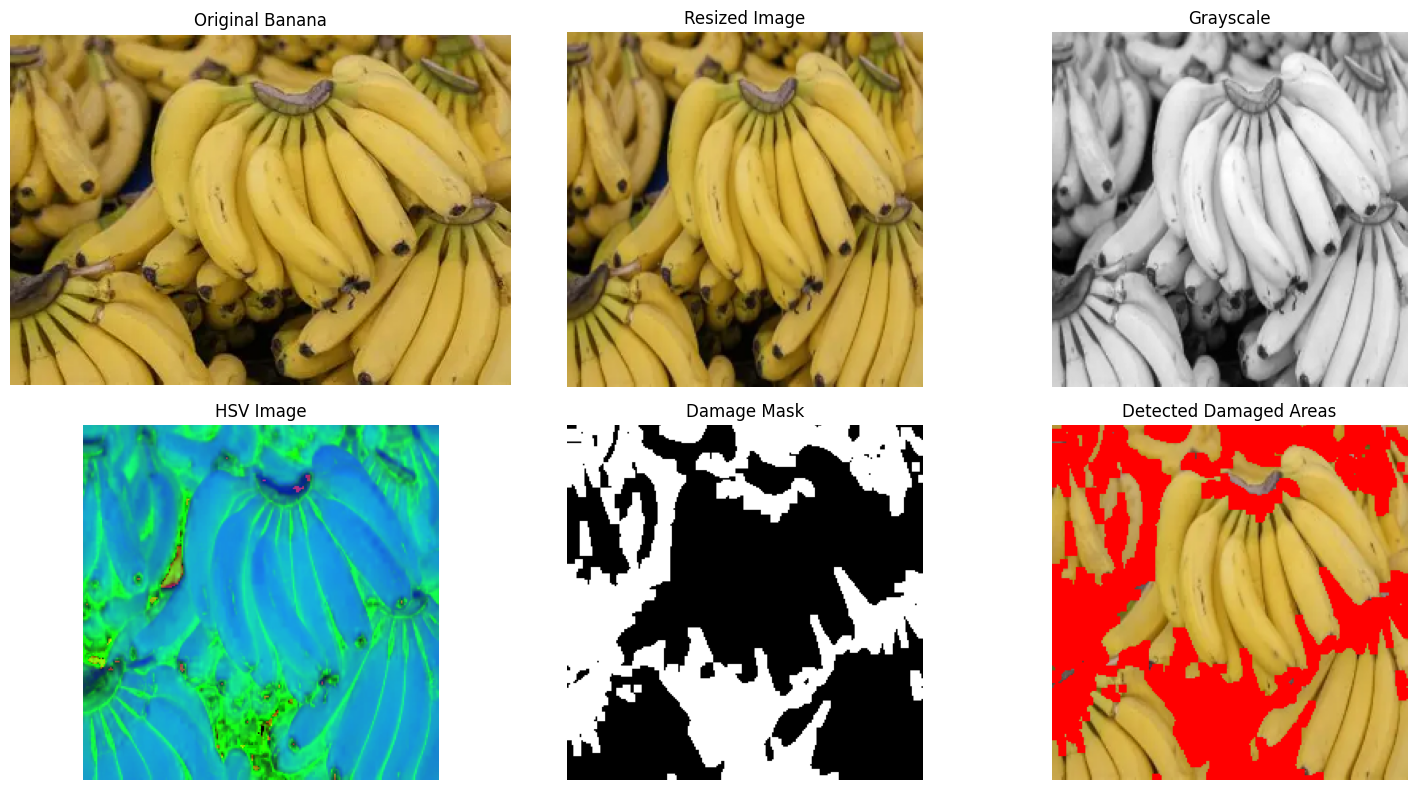

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(rgb_image)
plt.title("Original Banana")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask_image, cmap="gray")
plt.title("Damage Mask")
plt.axis("off")

# Highlight detected damaged regions
highlighted = resized.copy()
highlighted[mask_image > 0] = [255, 0, 0]

plt.subplot(2, 3, 6)
plt.imshow(highlighted)
plt.title("Detected Damaged Areas")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# You can adjust this threshold
THRESHOLD = 8

if damage_percentage >= THRESHOLD:
    result = "BAD BANANA"
else:
    result = "GOOD BANANA"

print("=" * 40)
print("          BANANA QUALITY RESULT")
print("=" * 40)
print("Damage percentage:", round(damage_percentage, 2), "%")
print("Prediction:", result)
print("=" * 40)

          BANANA QUALITY RESULT
Damage percentage: 40.28 %
Prediction: BAD BANANA
